In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.linalg import ldl
from scipy.linalg import expm,logm
import numpy.linalg as linalg
from scipy.linalg import ishermitian

In [2]:
Nlist = [3,10,20,100]
#Nlist = [3]

eigValList = []

for N0 in Nlist :
    
    I0 = 20
    V0 = 1
    
    lenH = 2*N0 + 1
    
    H = np.zeros((lenH,lenH),dtype = complex)
    #print(H)
    
    for m1 in range(-N0,N0+1):
        for n1 in range(-N0,N0+1):
            i = m1 + N0
            j = n1 + N0
    
            Hij  = 0
            if n1 == m1 :
                Hij = Hij + n1**2/(2*I0) + V0/2
            elif n1 + 3 == m1 or n1 - 3  == m1 :
                Hij = Hij - V0/4         
            
            H[i,j] = Hij
            
    [Heigs,Hvecs] = np.linalg.eig(H)
    #HeigsReal = [float(eigVal) for eigVal in Heigs]
    #idx = Heigs.argsort()
    #HeigsSort = Heigs[idx]
    #HvecsSort = Hvecs[:,idx]
    [HeigsSort,HvecsSort] = np.linalg.eigh(H)
    
    eigValList.append(HeigsSort[0:6])
    
    
    #print(H)

In [3]:
eigValList

[array([0.24147945, 0.30970314, 0.30970314, 0.725     , 0.81529686,
        0.81529686]),
 array([0.22164423, 0.22228671, 0.22228671, 0.62473286, 0.62473286,
        0.63911782]),
 array([0.22164084, 0.22227646, 0.22227646, 0.62464897, 0.62464897,
        0.63908394]),
 array([0.22164084, 0.22227646, 0.22227646, 0.62464897, 0.62464897,
        0.63908394])]

In [4]:
HvecsSort

array([[ 0.00000000e+000+0.j,  0.00000000e+000+0.j, -6.73894071e-063+0.j,
        ...,  0.00000000e+000+0.j, -9.99856909e-001+0.j,
         0.00000000e+000+0.j],
       [ 4.07956144e-033+0.j, -8.72645292e-033+0.j, -2.52951723e-018+0.j,
        ..., -1.07642505e-041+0.j,  0.00000000e+000+0.j,
         1.36206509e-038+0.j],
       [-3.83369310e-033+0.j, -1.02988721e-032+0.j,  4.20862973e-018+0.j,
        ...,  1.06824221e-041+0.j,  0.00000000e+000+0.j,
        -1.46817258e-038+0.j],
       ...,
       [-6.16368935e-017+0.j, -3.14147579e-017+0.j,  1.23315657e-049+0.j,
        ...,  3.37134234e-020+0.j,  0.00000000e+000+0.j,
        -2.40032443e-018+0.j],
       [-8.41850144e-023+0.j,  7.44608964e-023+0.j, -2.38455208e-104+0.j,
        ..., -9.99853960e-001+0.j,  0.00000000e+000+0.j,
         3.52229546e-015+0.j],
       [-1.81835624e-021+0.j,  1.49549408e-021+0.j, -4.91923486e-100+0.j,
        ...,  3.52549851e-015+0.j,  0.00000000e+000+0.j,
         9.99856909e-001+0.j]])

In [5]:
H

array([[250.5  +0.j,   0.   +0.j,   0.   +0.j, ...,   0.   +0.j,
          0.   +0.j,   0.   +0.j],
       [  0.   +0.j, 245.525+0.j,   0.   +0.j, ...,   0.   +0.j,
          0.   +0.j,   0.   +0.j],
       [  0.   +0.j,   0.   +0.j, 240.6  +0.j, ...,   0.   +0.j,
          0.   +0.j,   0.   +0.j],
       ...,
       [  0.   +0.j,   0.   +0.j,   0.   +0.j, ..., 240.6  +0.j,
          0.   +0.j,   0.   +0.j],
       [  0.   +0.j,   0.   +0.j,   0.   +0.j, ...,   0.   +0.j,
        245.525+0.j,   0.   +0.j],
       [  0.   +0.j,   0.   +0.j,   0.   +0.j, ...,   0.   +0.j,
          0.   +0.j, 250.5  +0.j]])

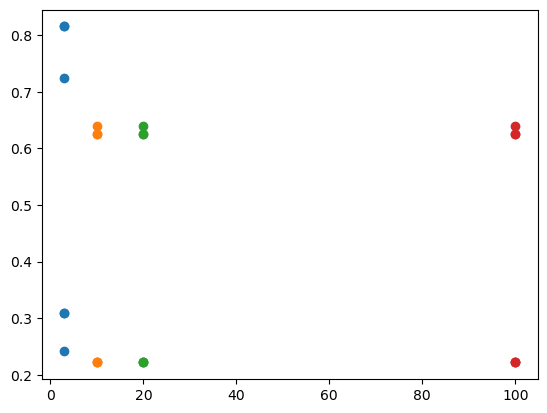

In [6]:
plt.plot(Nlist[0]*np.ones(6),eigValList[0],'o')
plt.plot(Nlist[1]*np.ones(6),eigValList[1],'o')
plt.plot(Nlist[2]*np.ones(6),eigValList[2],'o')
plt.plot(Nlist[3]*np.ones(6),eigValList[3],'o')

plt.show()

In [7]:
numPts = 1000
thetaList = np.linspace(0,2*np.pi,numPts)

V0 = 1
potE = V0*np.sin((3*thetaList/2))**2

Nv = 100

intList = range(-Nv,Nv+1)


In [8]:
#np.exp(1j*thetaList*1)

In [30]:
'''xn = range(-N0,N0+1)
#plt.plot(xn,HvecsSort[:,0],'o')
#plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')

fList = []

for j in range(0,6):
    fn = 0
    for n in range (-Nv,Nv+1):
        indNv = n + Nv
        fn = fn + HvecsSort[indNv,j]*np.exp(1j*thetaList*n)/np.sqrt(2*np.pi)
    
    fn = fn/np.sqrt(np.vdot(fn,fn))
    fList.append(fn)

    plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
    #plt.plot(thetaList, eigValList[3][j]*np.ones(numPts), linestyle = 'dashed')
    #plt.plot(thetaList, np.real(fn) + eigValList[3][j]*np.ones(numPts))
    plt.plot(thetaList, 100*fn*fn.conj())
    plt.axvline(x= 2*np.pi/3, color='red', linestyle='--', linewidth=2)
    plt.axvline(x= 0, color='red', linestyle='--', linewidth=2)
    #plt.plot(thetaList, np.real(fn))
    plt.show()
    plt.title('Psi Squared')
    
#plt.title('Real part of eigenfunctions')
#plt.legend()
#plt.show()


_IncompleteInputError: incomplete input (2298681602.py, line 1)

In [31]:
'''xn = range(-N0,N0+1)
#plt.plot(xn,HvecsSort[:,0],'o')
#plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')

fList = []

for j in range(0,6):
    fn = 0
    for n in range (-Nv,Nv+1):
        indNv = n + Nv
        fn = fn + HvecsSort[indNv,j]*np.exp(1j*thetaList*n)/np.sqrt(2*np.pi)
    
    fn = fn/np.sqrt(np.vdot(fn,fn))
    fList.append(fn)
    
    plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
    #plt.plot(thetaList, eigValList[3][j]*np.ones(numPts), linestyle = 'dashed')
    #plt.plot(thetaList, np.real(fn) + eigValList[3][j]*np.ones(numPts))
    plt.plot(thetaList, 10*np.real(fn))
    plt.axvline(x= 2*np.pi/3, color='red', linestyle='--', linewidth=2)
    plt.axvline(x= 0, color='red', linestyle='--', linewidth=2)
    #plt.plot(thetaList, np.real(fn))
    plt.show()
    plt.title('real part')
    
#plt.title('Real part of eigenfunctions')
#plt.legend()
#plt.show()

_IncompleteInputError: incomplete input (791676300.py, line 1)

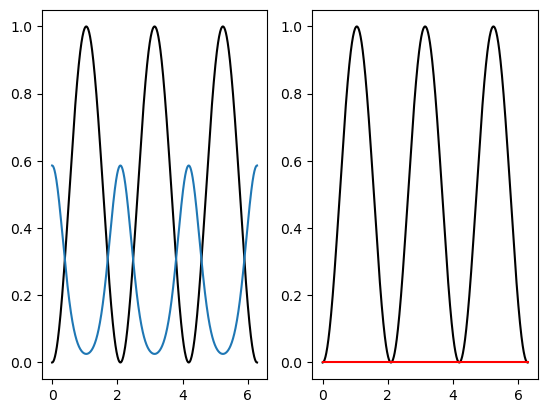

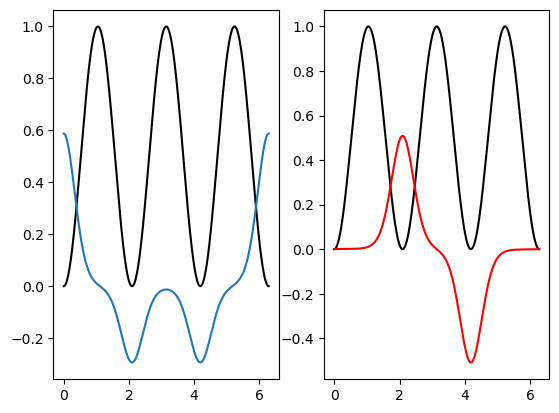

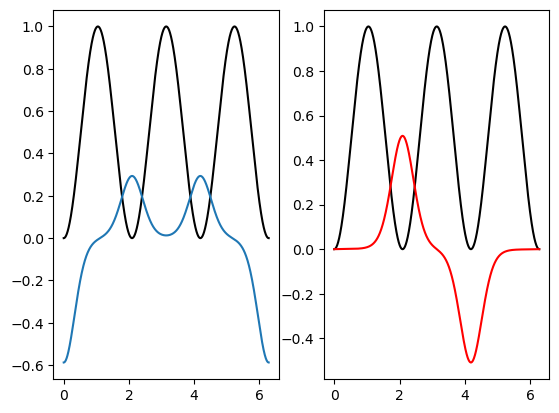

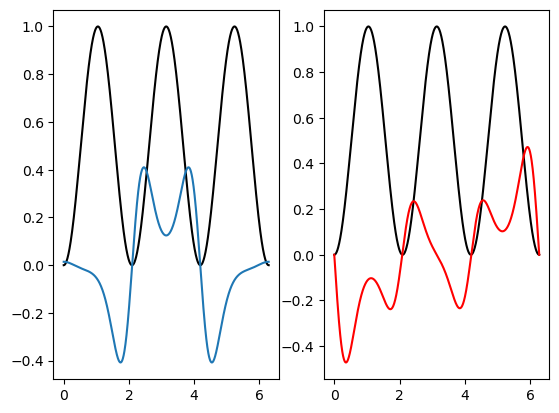

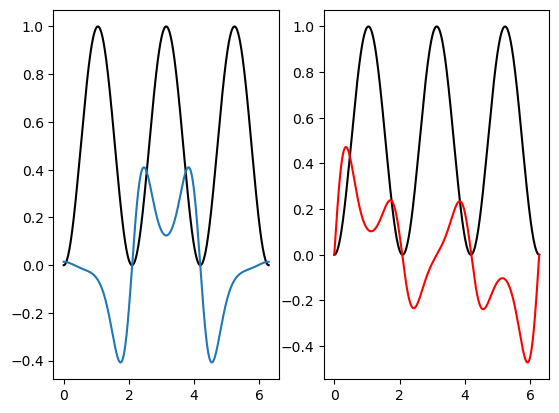

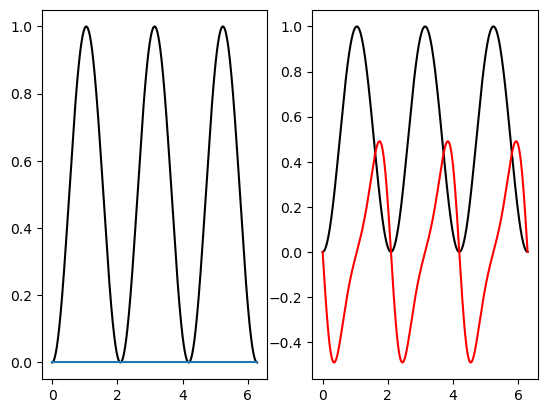

In [49]:
xn = range(-N0,N0+1)
#plt.plot(xn,HvecsSort[:,0],'o')
#plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')

fList = []

for j in range(0,6):
    fn = 0
    for n in range (-Nv,Nv+1):
        indNv = n + Nv
        fn = fn + HvecsSort[indNv,j]*np.exp(1j*thetaList*n)/np.sqrt(2*np.pi)
    
    fn = fn/np.sqrt(np.vdot(fn,fn))
    fList.append(fn)
    
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(thetaList, potE,'k',label = 'V(\u03B8)')
    ax2.plot(thetaList, potE,'k',label = 'V(\u03B8)')
    #plt.plot(thetaList, eigValList[3][j]*np.ones(numPts), linestyle = 'dashed')
    #plt.plot(thetaList, np.real(fn) + eigValList[3][j]*np.ones(numPts))
    ax1.plot(thetaList, 10*np.real(fn))
    ax2.plot(thetaList, 10*np.imag(fn),color = 'red')
    #plt.axvline(x= 2*np.pi/3, color='red', linestyle='--', linewidth=2)
    #plt.axvline(x= 0, color='red', linestyle='--', linewidth=2)
    #plt.plot(thetaList, np.real(fn))
    plt.show()
    ax1.set_title('real part')
    ax2.set_title('imaginary part')
    
#plt.title('Real part of eigenfunctions')
#plt.legend()
#plt.show()

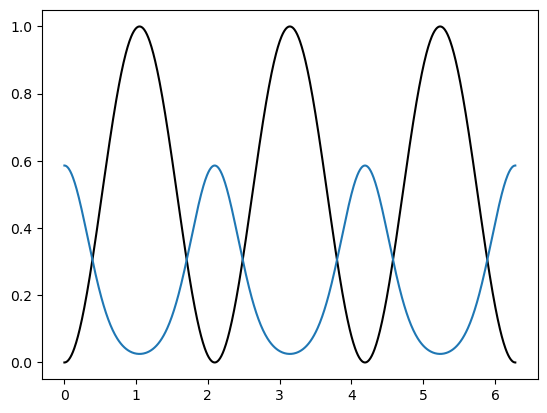

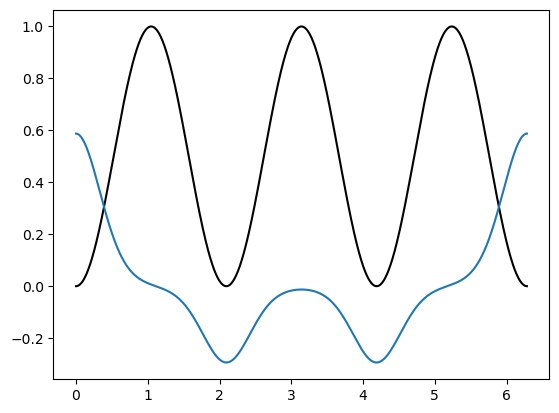

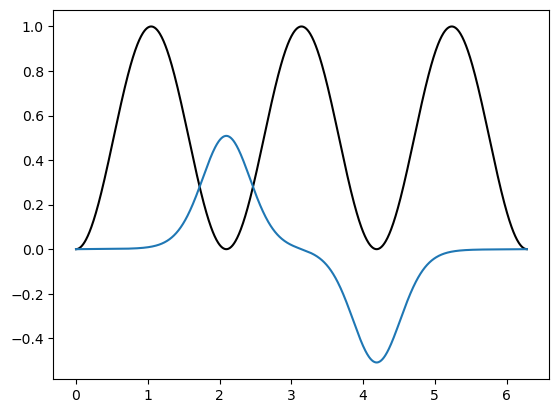

In [50]:
f1 = fList[0];
f2 = ( fList[1] - fList[2] ) / 2;
f3 = -1j*( fList[1] +  fList[2] ) / 2;

plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
plt.plot(thetaList,10*f1)
plt.show()
plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
plt.plot(thetaList,10*f2)
plt.show()
plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
plt.plot(thetaList,10*f3)
plt.show()

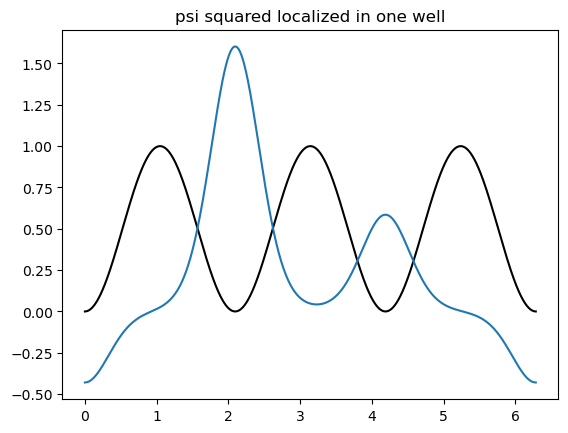

In [45]:
f1 = fList[0];
f2 = ( fList[1] - fList[2] ) / 2;
f3 = -1j*( fList[1] + fList[2] ) / 2;
vecLoc = f1 + f3 - 1.729 * f2 #-f1 #-1j/np.sqrt(2)*f2-1j/np.sqrt(2)*f3
vecLocNormSq = vecLoc #*vecLoc.conj()
#vecLocNormSq = vecLocNormSq/np.sqrt(np.vdot(vecLocNormSq,vecLocNormSq))

plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
plt.plot(thetaList,10*vecLocNormSq)
#plt.xlim(3.5,6)
#plt.ylim(-0.03,0.03)

plt.title('psi squared localized in one well')
plt.show()


In [13]:
HeigsSort[0:6]

array([0.22164084, 0.22227646, 0.22227646, 0.62464897, 0.62464897,
       0.63908394])

In [14]:
np.pi/(E2-E1)

NameError: name 'E2' is not defined

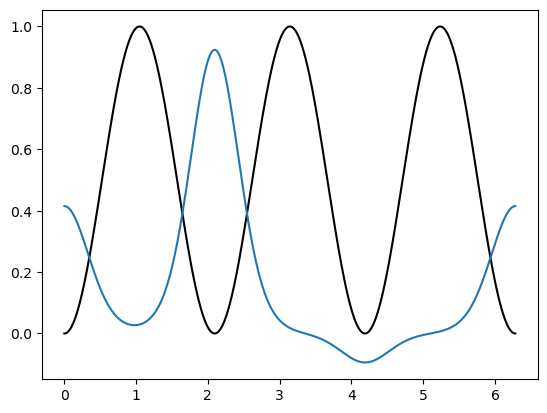

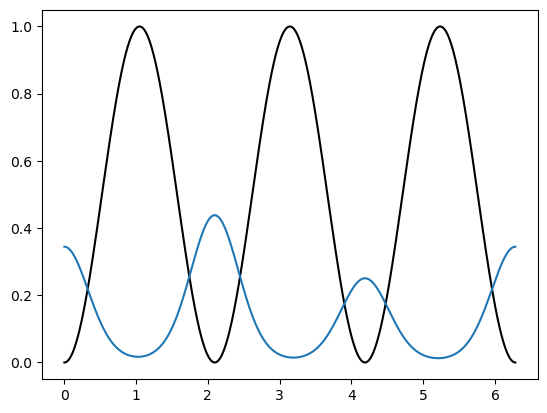

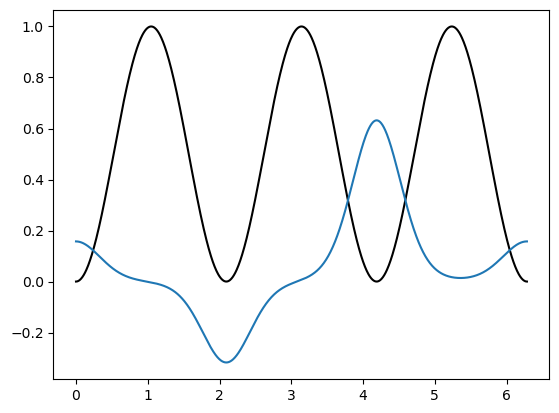

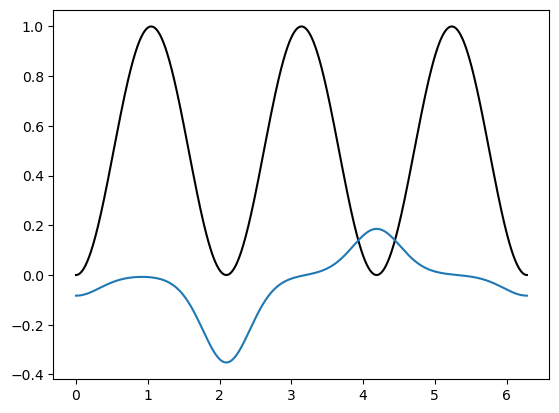

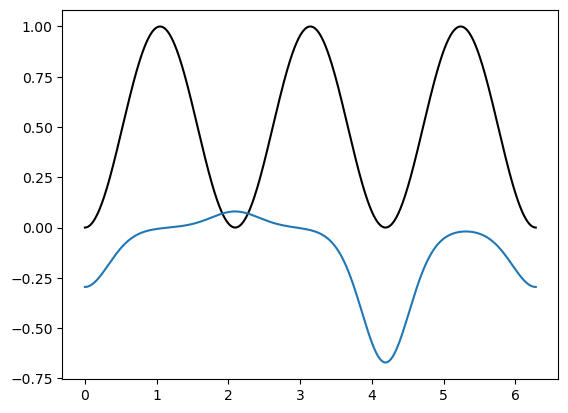

In [54]:
numTpts = 5
tMax = 5000
tauList = np.linspace(0,tMax,numTpts)

E1 = HeigsSort[0]
E2 = HeigsSort[1]
E3 = HeigsSort[2]

f1 = fList[0];
f2 = fList[1];
f3 = fList[2];

for tau in tauList:
    vecLoc = f1-1j/np.sqrt(2)*f2-1j/np.sqrt(2)*f3
    vecLocNorm = np.sqrt(np.vdot(vecLoc,vecLoc))

    vecTimeEvol = (np.exp(-1j*E1*tau)*f1-1j/np.sqrt(2)*np.exp(-1j*E2*tau)*f2-1j/np.sqrt(2)*np.exp(-1j*E3*tau)*f3) /(vecLocNorm )

    plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
    #plt.plot(thetaList,100*vecTimeEvol*vecTimeEvol.conj())
    plt.plot(thetaList,10*vecTimeEvol)

    #plt.title(['psi squared localized in one well at t =', num2str(tau)])
    plt.show()

In [55]:
thetaList

array([0.        , 0.00628947, 0.01257895, 0.01886842, 0.0251579 ,
       0.03144737, 0.03773685, 0.04402632, 0.0503158 , 0.05660527,
       0.06289475, 0.06918422, 0.0754737 , 0.08176317, 0.08805265,
       0.09434212, 0.1006316 , 0.10692107, 0.11321055, 0.11950002,
       0.1257895 , 0.13207897, 0.13836845, 0.14465792, 0.15094739,
       0.15723687, 0.16352634, 0.16981582, 0.17610529, 0.18239477,
       0.18868424, 0.19497372, 0.20126319, 0.20755267, 0.21384214,
       0.22013162, 0.22642109, 0.23271057, 0.23900004, 0.24528952,
       0.25157899, 0.25786847, 0.26415794, 0.27044742, 0.27673689,
       0.28302637, 0.28931584, 0.29560531, 0.30189479, 0.30818426,
       0.31447374, 0.32076321, 0.32705269, 0.33334216, 0.33963164,
       0.34592111, 0.35221059, 0.35850006, 0.36478954, 0.37107901,
       0.37736849, 0.38365796, 0.38994744, 0.39623691, 0.40252639,
       0.40881586, 0.41510534, 0.42139481, 0.42768429, 0.43397376,
       0.44026323, 0.44655271, 0.45284218, 0.45913166, 0.46542

In [ ]:
#fList

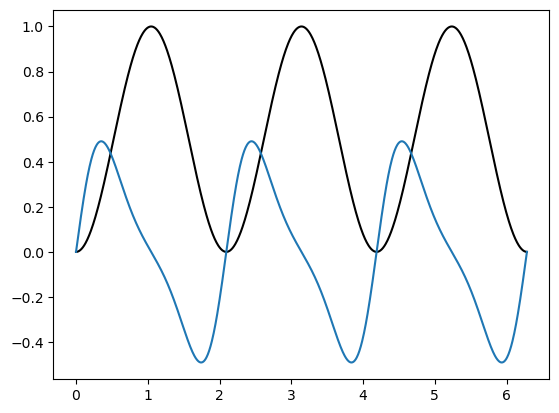

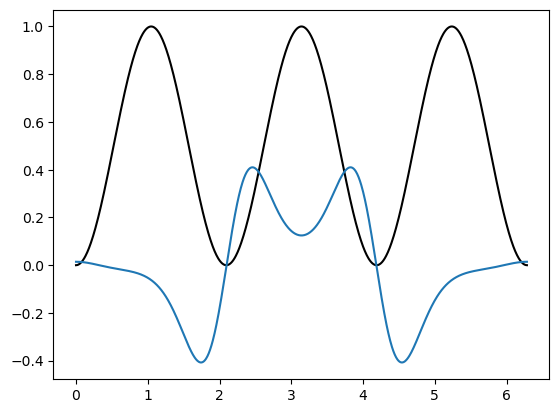

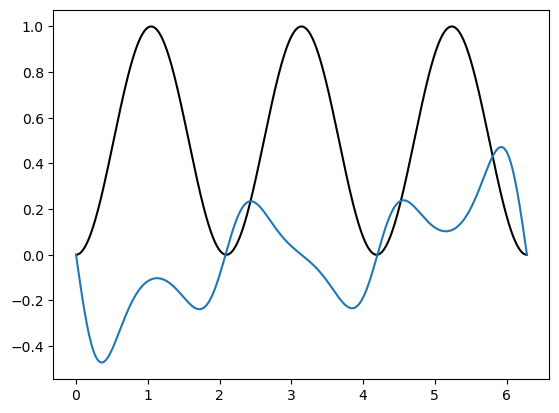

In [21]:
f4 = 1j*fList[5];
f5 = (fList[3]+fList[4])/2;
f6 = -1j*(fList[3]-fList[4])/2;

plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
plt.plot(thetaList,10*f4)
plt.show()
plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
plt.plot(thetaList,10*f5)
plt.show()
plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
plt.plot(thetaList,10*f6)
plt.show()

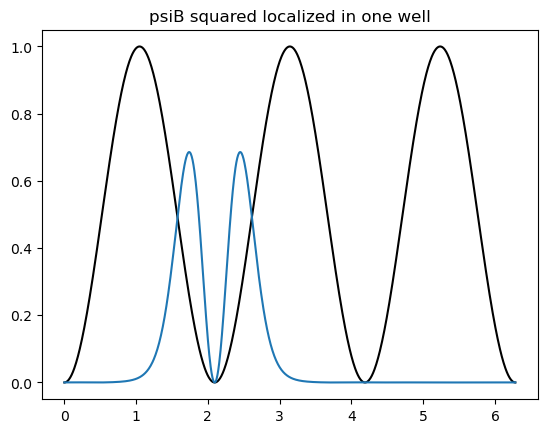

In [29]:


vecLocB = f4+1.729*f5+f6
vecLocB = vecLocB/np.sqrt(np.vdot(vecLocB,vecLocB))
vecLocNormSqB = vecLocB*vecLocB.conj()

plt.plot(thetaList, potE,'k',label = 'V(\u03B8)')
plt.plot(thetaList,100*vecLocNormSqB)

plt.title('psiB squared localized in one well')
plt.show()